In [ ]:
import os
import shutil

# 💣 reset runtime (opcional - comenta se não quiser reiniciar)
# os.kill(os.getpid(), 9)

# 🧹 limpar dataset antigo
if os.path.exists("dataset_raw"):
    shutil.rmtree("dataset_raw")

# 📁 recriar estrutura limpa
os.makedirs("dataset_raw/batman", exist_ok=True)
os.makedirs("dataset_raw/superman", exist_ok=True)

print("✅ Ambiente limpo e pronto")

✅ Ambiente limpo e pronto


In [ ]:
!pip install duckduckgo-search

In [ ]:
!pip install bing-image-downloader pillow tqdm

In [ ]:
!pip install icrawler

In [ ]:
import os

os.makedirs("dataset_raw/batman", exist_ok=True)
os.makedirs("dataset_raw/superman", exist_ok=True)

print("📁 Pastas criadas com sucesso")

📁 Pastas criadas com sucesso


In [ ]:
import os
print(os.listdir("dataset_raw"))

['batman', 'superman']


In [ ]:
from bing_image_downloader import downloader
import os
import shutil
import uuid
import time

# 📁 criar estrutura
os.makedirs("dataset_raw/batman", exist_ok=True)
os.makedirs("dataset_raw/superman", exist_ok=True)

# 🔧 CONFIG
NUM_IMAGENS = 30
DELAY = 2  # evita travar

buscas_batman = [
    "Christian Bale Batman movie still",
    "Ben Affleck Batman Justice League scene",
    "Batman Dark Knight film still"
]

buscas_superman = [
    "Henry Cavill Superman Man of Steel scene",
    "Henry Cavill Superman close up",
    "Superman movie still cinematic"
]

# 🧠 mover imagens e evitar sobrescrever
def mover_e_organizar(pasta_classe):
    total = 0

    for subpasta in os.listdir(pasta_classe):
        caminho = os.path.join(pasta_classe, subpasta)

        if os.path.isdir(caminho):
            for file in os.listdir(caminho):
                origem = os.path.join(caminho, file)

                novo_nome = f"{uuid.uuid4()}.jpg"
                destino = os.path.join(pasta_classe, novo_nome)

                shutil.move(origem, destino)
                total += 1

            # remove pasta vazia
            shutil.rmtree(caminho)

    print(f"📦 {pasta_classe}: {total} imagens organizadas")

# 🧠 contador rápido
def contar_imagens(pasta):
    return len(os.listdir(pasta))

# 🚀 download com controle
def baixar_lista(buscas, classe):
    pasta = f"dataset_raw/{classe}"

    for busca in buscas:
        print(f"\n🔎 Baixando: {busca}")

        downloader.download(
            busca,
            limit=NUM_IMAGENS,
            output_dir=pasta,
            adult_filter_off=True,
            force_replace=False,
            timeout=20
        )

        # organizar imediatamente (evita bagunça)
        mover_e_organizar(pasta)

        print(f"📊 Total atual ({classe}): {contar_imagens(pasta)}")

        time.sleep(DELAY)

# 🚀 EXECUÇÃO
baixar_lista(buscas_batman, "batman")
baixar_lista(buscas_superman, "superman")


🔎 Baixando: Christian Bale Batman movie still
[%] Downloading Images to /content/dataset_raw/batman/Christian Bale Batman movie still


[!!]Indexing page: 1

[%] Indexed 30 Images on Page 1.


[%] Downloading Image #1 from https://wallpapers.com/images/hd/batman-with-christian-bale-movie-8rf9smnf1u5nl53g.jpg
[%] File Downloaded !

[%] Downloading Image #2 from https://static1.moviewebimages.com/wordpress/wp-content/uploads/2022/04/3C970E32-6416-4311-8DE3-FCC62AA3717B.jpg
[%] File Downloaded !

[%] Downloading Image #3 from http://fc01.deviantart.net/fs70/i/2012/100/8/9/christian_bale___batman_by_jawz270589-d4vnap2.jpg
[%] File Downloaded !

[%] Downloading Image #4 from https://images.thedirect.com/media/article_full/christian-bale-flash-batman.jpg
[%] File Downloaded !

[%] Downloading Image #5 from https://static1.moviewebimages.com/wordpress/wp-content/uploads/2023/08/bale-in-batman-begins.jpg
[%] File Downloaded !

[%] Downloading Image #6 from https://images.thedirect.com/media/a

In [ ]:
import os

print(os.listdir("dataset_raw/superman")[:5])

['c940b2a6-fdb1-4b58-b1cf-0a484b5605db.jpg', '617705dd-9013-452c-b007-3c361ca76537.jpg', 'b0162aef-f55d-4c56-9a86-dd46ee695558.jpg', '38f5cb49-a196-457c-9d8e-ee88285770c8.jpg', 'b2d23c2d-7323-4467-af2e-87a8d553a077.jpg']


In [ ]:
import os
import time
import requests
import random
import uuid
from duckduckgo_search import DDGS
from PIL import Image
from tqdm import tqdm

# 📁 pastas
os.makedirs("dataset_raw/batman", exist_ok=True)
os.makedirs("dataset_raw/superman", exist_ok=True)

# 🔧 CONFIG
MAX_IMAGENS = 60
DELAY_MIN = 1.0
DELAY_MAX = 2.5
DELAY_BUSCA = 8
MAX_RETRIES = 3
TIMEOUT = 5
MIN_SIZE = 150  # 🔥 filtro importante

session = requests.Session()
session.headers.update({"User-Agent": "Mozilla/5.0"})

# 🧠 salvar imagem melhorado
def salvar_imagem(url, pasta):
    try:
        response = session.get(url, timeout=TIMEOUT)
        if response.status_code != 200:
            return False

        filename = os.path.join(pasta, f"{uuid.uuid4()}.jpg")

        with open(filename, "wb") as f:
            f.write(response.content)

        # 🔥 validação REAL
        img = Image.open(filename)
        img = img.convert("RGB")

        # 🔥 filtro de tamanho
        if img.size[0] < MIN_SIZE or img.size[1] < MIN_SIZE:
            os.remove(filename)
            return False

        # 🔥 salva novamente normalizada
        img.save(filename, "JPEG")

        return True

    except:
        if 'filename' in locals() and os.path.exists(filename):
            os.remove(filename)
        return False

# 🧠 delay inteligente
def esperar():
    time.sleep(random.uniform(DELAY_MIN, DELAY_MAX))

# 🧠 download principal
def baixar_imagens(query, pasta):
    print(f"\n🔎 Buscando: {query}")

    urls_vistas = set()  # 🔥 evita duplicadas

    for tentativa in range(MAX_RETRIES):
        try:
            with DDGS() as ddgs:
                resultados = list(ddgs.images(query, max_results=MAX_IMAGENS * 2))

            count = 0

            for r in tqdm(resultados):
                if count >= MAX_IMAGENS:
                    break

                url = r.get("image")
                if not url or url in urls_vistas:
                    continue

                urls_vistas.add(url)

                sucesso = salvar_imagem(url, pasta)

                if sucesso:
                    count += 1

                esperar()

            print(f"✅ {count} imagens válidas salvas")
            return

        except Exception as e:
            print(f"⚠️ Tentativa {tentativa+1} falhou: {e}")
            time.sleep(10 + tentativa * 5)

    print("❌ Falhou após várias tentativas")

# 🔵 BATMAN
buscas_batman = [
    "Christian Bale Batman movie still",
    "Ben Affleck Batman cinematic scene",
]

# 🔴 SUPERMAN
buscas_superman = [
    "Henry Cavill Superman movie still",
    "Henry Cavill Superman cinematic close up",
]

# 🚀 EXECUÇÃO
for busca in buscas_batman:
    baixar_imagens(busca, "dataset_raw/batman")
    print("⏸️ Pausando...")
    time.sleep(DELAY_BUSCA)

for busca in buscas_superman:
    baixar_imagens(busca, "dataset_raw/superman")
    print("⏸️ Pausando...")
    time.sleep(DELAY_BUSCA)


🔎 Buscando: Christian Bale Batman movie still


/tmp/ipykernel_5869/2006168070.py:69: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use tim

⚠️ Tentativa 1 falhou: https://duckduckgo.com/i.js?o=json&q=Christian+Bale+Batman+movie+still&l=us-en&vqd=4-285083062814521419133587361659330013930&p=1&f=%2C%2C%2C%2C%2C 403 Ratelimit


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

⚠️ Tentativa 2 falhou: https://duckduckgo.com/i.js?o=json&q=Christian+Bale+Batman+movie+still&l=us-en&vqd=4-285083062814521419133587361659330013930&p=1&f=%2C%2C%2C%2C%2C 403 Ratelimit


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

⚠️ Tentativa 3 falhou: https://duckduckgo.com/i.js?o=json&q=Henry+Cavill+Superman+cinematic+close+up&l=us-en&vqd=4-276037384709478416221344513096984695861&p=1&f=%2C%2C%2C%2C%2C 403 Ratelimit


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

❌ Falhou após várias tentativas
⏸️ Pausando...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
from icrawler.builtin import GoogleImageCrawler
import os
import time
import uuid
import shutil

# 📁 pastas
os.makedirs("dataset_raw/batman", exist_ok=True)
os.makedirs("dataset_raw/superman", exist_ok=True)

# 🧠 função para renomear e limpar
def organizar_pasta(pasta):
    count = 0

    for file in os.listdir(pasta):
        caminho = os.path.join(pasta, file)

        if not os.path.isfile(caminho):
            continue

        ext = os.path.splitext(file)[1].lower()

        # só mantém imagens válidas
        if ext not in [".jpg", ".jpeg", ".png"]:
            os.remove(caminho)
            continue

        novo_nome = f"{uuid.uuid4()}.jpg"
        novo_caminho = os.path.join(pasta, novo_nome)

        os.rename(caminho, novo_caminho)
        count += 1

    print(f"📦 {count} imagens organizadas em {pasta}")

# 🧠 função principal
def baixar_google(buscas, pasta, max_por_busca=30):

    for busca in buscas:
        print(f"\n🔎 Google buscando: {busca}")

        crawler = GoogleImageCrawler(
            storage={'root_dir': pasta},
            downloader_threads=1,   # 🔥 menos threads = menos bloqueio
            parser_threads=1
        )

        crawler.crawl(
            keyword=busca,
            max_num=max_por_busca,
            filters={
                "type": "photo",
                "size": "large",
            }
        )

        # 🔥 organiza depois de cada busca
        organizar_pasta(pasta)

        # 🔥 pausa anti-bloqueio
        tempo = 10
        print(f"⏸️ Pausando {tempo}s...")
        time.sleep(tempo)

# 🔵 BATMAN (melhoradas)
buscas_batman = [
    "Christian Bale Batman movie still",
    "Ben Affleck Batman Justice League scene",
]

# 🔴 SUPERMAN
buscas_superman = [
    "Henry Cavill Superman Man of Steel scene",
    "Henry Cavill Superman cinematic close up",
]

# 🚀 execução
baixar_google(buscas_batman, "dataset_raw/batman")
baixar_google(buscas_superman, "dataset_raw/superman")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import os

def analisar_pasta(pasta):
    arquivos = os.listdir(pasta)
    total = len(arquivos)

    print(f"\n📂 Pasta: {pasta}")
    print(f"📊 Total de imagens: {total}")

    # mostra alguns exemplos
    print("🔍 Exemplos:")
    for f in arquivos[:5]:
        print(" -", f)

# analisar dataset
analisar_pasta("dataset_raw/batman")
analisar_pasta("dataset_raw/superman")


📂 Pasta: dataset_raw/batman
📊 Total de imagens: 90
🔍 Exemplos:
 - c0ed9ecd-326b-42b6-a06d-b9a4068102bb.jpg
 - b6ed24a8-951e-42a0-98f3-2933b14a97c5.jpg
 - be09eb4b-0ef0-441c-abcf-47dede0fac11.jpg
 - 4d37977a-dad1-4134-88dd-09d2ba44d53d.jpg
 - 698ab35d-f700-44bc-bf2c-797b783b33cb.jpg

📂 Pasta: dataset_raw/superman
📊 Total de imagens: 90
🔍 Exemplos:
 - 0b73e97e-e385-4b82-a21b-bb423e7910a7.jpg
 - 142bd01b-2d4c-48fc-9bf7-e8058b93a027.jpg
 - 982af826-3a38-4ba0-9091-a50661ea4028.jpg
 - c5310d4e-675a-40aa-8dda-cfe105561e89.jpg
 - 84c63848-b402-4ffc-b1b0-e54265f9fecb.jpg


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import os
import time
import uuid
from icrawler.builtin import GoogleImageCrawler
from PIL import Image


# 🔇 remove warnings chatos
import warnings
warnings.filterwarnings("ignore")

# 📁 garantir pastas
os.makedirs("dataset_raw/batman", exist_ok=True)
os.makedirs("dataset_raw/superman", exist_ok=True)

# 🔧 CONFIG
MAX_POR_BUSCA = 35
DELAY_ENTRE_BUSCAS = 12

# 🧠 limpar + organizar imagens
def organizar_pasta(pasta):
    count = 0
    removidos = 0

    for file in os.listdir(pasta):
        caminho = os.path.join(pasta, file)

        if not os.path.isfile(caminho):
            continue

        if file.endswith(".jpg") and len(file) > 30:
            continue

        try:
            img = Image.open(caminho)
            img.verify()

            img = Image.open(caminho).convert("RGB")

            # 🔥 filtro de tamanho
            if img.size[0] < 150 or img.size[1] < 150:
                os.remove(caminho)
                continue

            novo_nome = f"{uuid.uuid4()}.jpg"
            novo_caminho = os.path.join(pasta, novo_nome)

            img.save(novo_caminho, "JPEG")
            os.remove(caminho)

            count += 1

        except:
            if os.path.exists(caminho):
                os.remove(caminho)
                removidos += 1

    print(f"📦 {count} novas | 🧹 {removidos} removidas | 📁 {pasta}")

# 🧠 função principal
def baixar_google(buscas, pasta):

    for busca in buscas:
        print(f"\n🔎 Google buscando: {busca}")

        crawler = GoogleImageCrawler(
            storage={'root_dir': pasta},
            downloader_threads=1,   # 🔥 evita bloqueio
            parser_threads=1
        )

        try:
            crawler.crawl(
                keyword=busca,
                max_num=MAX_POR_BUSCA,
                filters={
                    "type": "photo",   # evita desenho
                    "size": "large",   # melhor qualidade
                }
            )

        except Exception as e:
            print(f"⚠️ Erro ignorado: {e}")

        # 🔥 organiza após cada busca
        organizar_pasta(pasta)

        # 🔥 pausa anti-bloqueio
        print(f"⏸️ Pausando {DELAY_ENTRE_BUSCAS}s...")
        time.sleep(DELAY_ENTRE_BUSCAS)

buscas_batman = [
    "Christian Bale Bruce Wayne close up",
    "Ben Affleck Bruce Wayne face",
    "Batman Dark Knight trilogy scene high quality",
]

buscas_superman = [
    "Henry Cavill Clark Kent close up",
    "Henry Cavill Superman face high resolution",
    "Man of Steel Superman scene HD",
]

# 🚀 EXECUÇÃO
baixar_google(buscas_batman, "dataset_raw/batman")
baixar_google(buscas_superman, "dataset_raw/superman")

print("\n✅ Download Google finalizado!")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


🔎 Google buscando: Christian Bale Batman dark knight scene
📦 90 imagens válidas em dataset_raw/batman
⏸️ Pausando 12s...


Exception in thread parser-001:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/icrawler/parser.py", line 93, in worker_exec
    for task in self.parse(response, **kwargs):
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable



🔎 Google buscando: Ben Affleck Batman justice league close up
📦 90 imagens válidas em dataset_raw/batman
⏸️ Pausando 12s...


Exception in thread parser-001:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/icrawler/parser.py", line 93, in worker_exec
    for task in self.parse(response, **kwargs):
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable


...


🔎 Google buscando: Henry Cavill Superman man of steel scene
📦 90 imagens válidas em dataset_raw/superman
⏸️ Pausando 12s...


Exception in thread parser-001:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/icrawler/parser.py", line 93, in worker_exec
    for task in self.parse(response, **kwargs):
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable



🔎 Google buscando: Henry Cavill Superman close up face
📦 90 imagens válidas em dataset_raw/superman
⏸️ Pausando 12s...


Exception in thread parser-001:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/icrawler/parser.py", line 93, in worker_exec
    for task in self.parse(response, **kwargs):
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable



🔎 Google buscando: Superman movie still cinematic
📦 90 imagens válidas em dataset_raw/superman
⏸️ Pausando 12s...

✅ Download Google finalizado!


In [15]:
import os
import time
import uuid
from icrawler.builtin import GoogleImageCrawler
from PIL import Image
import warnings

warnings.filterwarnings("ignore")

# 📁 garantir pastas
os.makedirs("dataset_raw/batman", exist_ok=True)
os.makedirs("dataset_raw/superman", exist_ok=True)

# 🔧 CONFIG (MAIS LEVE)
MAX_POR_BUSCA = 20
DELAY_ENTRE_BUSCAS = 15

# 🧠 limpar + organizar (só novas imagens)
def organizar_pasta(pasta):
    count = 0
    removidos = 0

    for file in os.listdir(pasta):
        caminho = os.path.join(pasta, file)

        if not os.path.isfile(caminho):
            continue

        # 🔥 já processado (UUID.jpg) → ignora
        if file.endswith(".jpg") and len(file) > 30:
            continue

        try:
            img = Image.open(caminho)
            img.verify()

            img = Image.open(caminho).convert("RGB")

            # 🔥 filtro de qualidade
            if img.size[0] < 150 or img.size[1] < 150:
                os.remove(caminho)
                continue

            novo_nome = f"{uuid.uuid4()}.jpg"
            novo_caminho = os.path.join(pasta, novo_nome)

            img.save(novo_caminho, "JPEG")
            os.remove(caminho)

            count += 1

        except:
            if os.path.exists(caminho):
                os.remove(caminho)
                removidos += 1

    print(f"📦 {count} novas | 🧹 {removidos} removidas | 📁 {pasta}")


# 🧠 função principal (melhorada)
def baixar_google(buscas, pasta):
    print(f"\n📂 Salvando em: {pasta}")

    for i, busca in enumerate(buscas, 1):
        print(f"\n🔎 ({i}/{len(buscas)}) Google buscando: {busca}")

        crawler = GoogleImageCrawler(
            storage={'root_dir': pasta},
            downloader_threads=1,
            parser_threads=1
        )

        try:
            crawler.crawl(
                keyword=busca,
                max_num=MAX_POR_BUSCA,
                filters={
                    "type": "photo",
                    "size": "large",
                }
            )
        except Exception as e:
            print(f"⚠️ Erro ignorado: {e}")

        organizar_pasta(pasta)

        print(f"⏸️ Pausando {DELAY_ENTRE_BUSCAS}s...")
        time.sleep(DELAY_ENTRE_BUSCAS)


# 🔵 buscas melhores
buscas_batman = [
    "Christian Bale Bruce Wayne close up",
    "Ben Affleck Bruce Wayne face",
    "Batman Dark Knight trilogy scene high quality",
]

buscas_superman = [
    "Henry Cavill Clark Kent close up",
    "Henry Cavill Superman face high resolution",
    "Man of Steel Superman scene HD",
]

# 🚀 EXECUÇÃO CONTROLADA

# 🔹 roda um por vez (evita travar)
baixar_google(buscas_batman, "dataset_raw/batman")

# ⏸️ pausa maior entre classes
print("\n⏸️ Pausa entre classes...")
time.sleep(20)

baixar_google(buscas_superman, "dataset_raw/superman")

print("\n✅ Download Google finalizado!")

Exception in thread parser-001:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/icrawler/parser.py", line 93, in worker_exec
    for task in self.parse(response, **kwargs):
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable



📂 Salvando em: dataset_raw/batman

🔎 (1/3) Google buscando: Christian Bale Bruce Wayne close up
📦 0 novas | 🧹 0 removidas | 📁 dataset_raw/batman
⏸️ Pausando 15s...


Exception in thread parser-001:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/icrawler/parser.py", line 93, in worker_exec
    for task in self.parse(response, **kwargs):
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable



🔎 (2/3) Google buscando: Ben Affleck Bruce Wayne face
📦 0 novas | 🧹 0 removidas | 📁 dataset_raw/batman
⏸️ Pausando 15s...


Exception in thread parser-001:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/icrawler/parser.py", line 93, in worker_exec
    for task in self.parse(response, **kwargs):
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable


...


📂 Salvando em: dataset_raw/superman

🔎 (1/3) Google buscando: Henry Cavill Clark Kent close up
📦 0 novas | 🧹 0 removidas | 📁 dataset_raw/superman
⏸️ Pausando 15s...


Exception in thread parser-001:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/icrawler/parser.py", line 93, in worker_exec
    for task in self.parse(response, **kwargs):
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable



🔎 (2/3) Google buscando: Henry Cavill Superman face high resolution
📦 0 novas | 🧹 0 removidas | 📁 dataset_raw/superman
⏸️ Pausando 15s...


Exception in thread parser-001:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/icrawler/parser.py", line 93, in worker_exec
    for task in self.parse(response, **kwargs):
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable



🔎 (3/3) Google buscando: Man of Steel Superman scene HD
📦 0 novas | 🧹 0 removidas | 📁 dataset_raw/superman
⏸️ Pausando 15s...

✅ Download Google finalizado!


In [16]:
import os

print("Batman:", len(os.listdir("dataset_raw/batman")))
print("Superman:", len(os.listdir("dataset_raw/superman")))

Batman: 90
Superman: 90


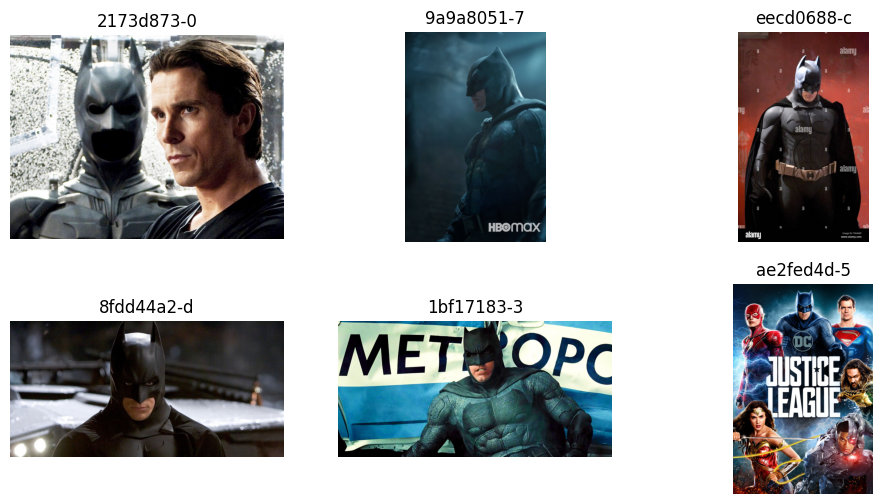

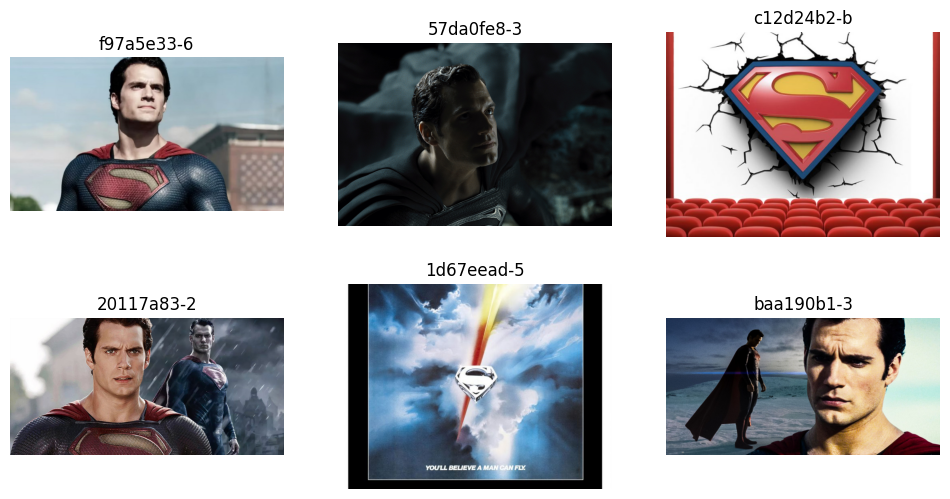

In [18]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

def mostrar_imagens(pasta, n=6):
    arquivos = os.listdir(pasta)

    if len(arquivos) == 0:
        print("⚠️ Pasta vazia")
        return

    amostra = random.sample(arquivos, min(n, len(arquivos)))

    plt.figure(figsize=(12,6))

    for i, file in enumerate(amostra):
        caminho = os.path.join(pasta, file)
        img = Image.open(caminho)

        plt.subplot(2, 3, i+1)
        plt.imshow(img)
        plt.title(file[:10])
        plt.axis("off")

    plt.show()

# testar
mostrar_imagens("dataset_raw/batman")
mostrar_imagens("dataset_raw/superman")

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# 🔧 CONFIG
BATCH_SIZE = 16
EPOCHS = 5
IMG_SIZE = 224

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando:", device)

# 📸 TRANSFORMS
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

# 📂 DATASET
dataset = datasets.ImageFolder("dataset_raw", transform=transform)

train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

print("Classes:", dataset.classes)

# 🧠 MODELO (transfer learning)
model = models.resnet18(pretrained=True)

# 🔥 trocar última camada (2 classes)
model.fc = nn.Linear(model.fc.in_features, 2)

model = model.to(device)

# 🔧 LOSS + OTIMIZADOR
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 🚀 TREINO
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {total_loss:.4f}")

print("✅ Treinamento finalizado!")

Usando: cpu
Classes: ['batman', 'superman']
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 159MB/s]


Epoch 1/5 - Loss: 10.9182
Epoch 2/5 - Loss: 5.5817
Epoch 3/5 - Loss: 4.6374
Epoch 4/5 - Loss: 5.8458
Epoch 5/5 - Loss: 4.5368
✅ Treinamento finalizado!


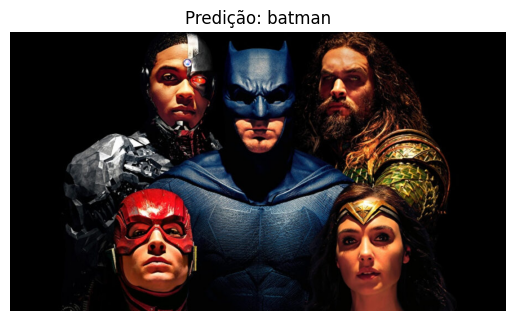

In [20]:
from PIL import Image
import torch
import matplotlib.pyplot as plt
from torchvision import transforms

# 🔧 mesma transformação
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# 🖼️ carregar imagem (troca pelo caminho)
img_path = "dataset_raw/batman/" + os.listdir("dataset_raw/batman")[0]

img = Image.open(img_path).convert("RGB")
input_tensor = transform(img).unsqueeze(0).to(device)

# 🔮 prever
model.eval()
with torch.no_grad():
    output = model(input_tensor)
    _, pred = torch.max(output, 1)

classes = ['batman', 'superman']

# 📊 resultado
plt.imshow(img)
plt.title(f"Predição: {classes[pred.item()]}")
plt.axis("off")
plt.show()

In [21]:
torch.save(model.state_dict(), "model.pth")

In [22]:
from google.colab import files
files.download("model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>